- Learning with the MSELoss seems almost impossible
- KLDiv loss seems to help learning process though there are no results yet
- GAN does not care about loss and still does not work even though it seems to be learning

## co zatial funguje
 - pokial zmenim loss na MSE som schopny izolovat tieto body zaujimave neviem ci uzitocne
    - body [8,  15, 188, 214, 263, 268, 520, 533, 546, 555]
 - BCE nedava moc vysledku

In [451]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [452]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [453]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [454]:
from src.load_sam_data import load_dataset
from src.plotting_styles import apply_global_style
from src.autoencoders import minmax_scale_per_sample
from src.autoencoders import drop_empty_histograms

data_dir = "FJ"
dataset = load_dataset(data_dir)
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

..\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [455]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [456]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [457]:
# baseline on linear layers

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        #self.conv1 = nn.Conv1d(in_channels=1, out_channels=3, kernel_size=3, stride=2)
        #self.conv2 = nn.Conv1d(in_channels=3, out_channels=9, kernel_size=3, stride=2)
        #self.conv3 = nn.Conv1d(in_channels=9, out_channels=16, kernel_size=3, stride=2)
        #self.fc = nn.Linear()
        self.conv1 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2)
        self.conv2 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2)
        self.fc1 = nn.Linear(86, 90)
        self.fc2 = nn.Linear(90, 96)
        #self.fc1 = nn.Linear(20, 36)
        #self.fc2 = nn.Linear(36, 64)
        #self.fc3 = nn.Linear(64, 72)
        #self.fc4 = nn.Linear(72, 96)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.fc1(x))
        x = F.sigmoid(self.fc2(x))
        return x
    
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        #self.conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=4, stride=2)
        #self.conv2 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=4, stride=2)
        #self.conv3 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=4, stride=2)
        #self.fc1 = nn.Linear(160, 64)
        #self.fc2 = nn.Linear(64, 1)

        self.fc1 = nn.Linear(96, 80)
        self.fc2 = nn.Linear(80, 60)
        self.fc3 = nn.Linear(60, 40)
        self.fc4 = nn.Linear(40, 1)
    
    def extract_features(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

    def forward(self, x):
        # first layer torch.Size([16, 4, 47])
        # second layer torch.Size([16, 8, 22])
        # third layer torch.Size([16, 16, 10])
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        #x = torch.flatten(x, start_dim=1)
        x = F.sigmoid(self.fc4(x))
        return x

In [458]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader

class HistDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        hist = self.data[idx]
        hist = torch.tensor(hist, dtype=torch.float32)
        return hist

In [488]:
batch_size = 32

torch_df = HistDataset(full_dataset)
dataloader = DataLoader(torch_df, batch_size=batch_size, shuffle=True)
#train_dataset = HistDataset(X_train)
#test_dataset = HistDataset(X_test)

#train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

gen = Generator()
disc = Discriminator()

lr = 0.0002
num_epochs = 200
latent_dim = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [489]:
#criterion = nn.MSELoss()
criterion = nn.MSELoss()
optimizer_G = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.9, 0.9999))
optimizer_D = torch.optim.Adam(disc.parameters(), lr=lr, betas=(0.9, 0.9999))

In [490]:
losses_D = []
losses_G = []

point_dim = len(dataset[0])

for epoch in range(num_epochs):
    for i, real_data in enumerate(dataloader):

        batch_size = real_data.size(0)
        
        real_labels = torch.ones(batch_size, 1, 1, device=device) 
        fake_labels = torch.zeros(batch_size, 1, 1, device=device)

        # gener train
        optimizer_D.zero_grad()
        real_data = real_data.reshape(batch_size, 1, point_dim)    
        
        # real data
        outputs_real = disc(real_data) # 16 x 96
        loss_real = criterion(outputs_real, real_labels)
        
        # generated data
        z = torch.randn(batch_size, 1, latent_dim, device=device)
        
        fake_data = gen(z) # output: 16 x 96
       
        outputs_fake = disc(fake_data.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # discr train
        optimizer_G.zero_grad()
        outputs_on_fake = disc(fake_data)
        
        # gen tricking disc
        loss_G = criterion(outputs_on_fake, real_labels)
        loss_G.backward()
        optimizer_G.step()
        
    losses_D.append(loss_D.item())
    losses_G.append(loss_G.item())

    if epoch % 20 == 0:
        print(f"Ep {epoch+1}/{num_epochs} Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

C:\Users\hrdyj\AppData\Local\Temp\ipykernel_14764\2451661108.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hist = torch.tensor(hist, dtype=torch.float32)


Ep 1/200 Loss D: 0.4838, Loss G: 0.2424
Ep 21/200 Loss D: 0.5812, Loss G: 0.1769
Ep 41/200 Loss D: 0.6991, Loss G: 0.2357
Ep 61/200 Loss D: 0.2554, Loss G: 0.4863
Ep 81/200 Loss D: 0.0506, Loss G: 0.7477
Ep 101/200 Loss D: 0.0724, Loss G: 0.7799
Ep 121/200 Loss D: 0.4796, Loss G: 0.5973
Ep 141/200 Loss D: 1.0005, Loss G: 0.9572
Ep 161/200 Loss D: 0.9168, Loss G: 0.9808
Ep 181/200 Loss D: 1.0001, Loss G: 0.9847


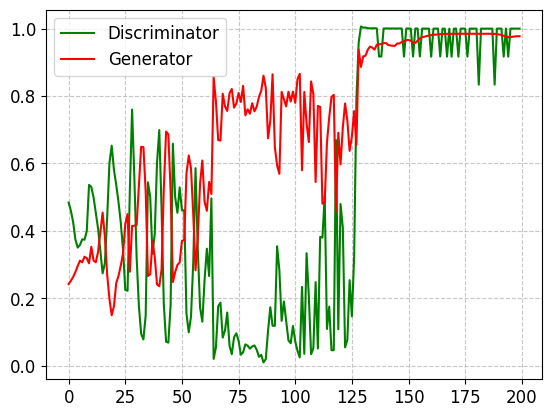

In [491]:
apply_global_style()
plt.plot(range(len(losses_D)), losses_D, color='green', label="Discriminator")
plt.plot(range(len(losses_G)), losses_G, color='red', label="Generator")
plt.legend()
plt.show()

In [492]:
hist = dataset[0]
hist = torch.tensor(hist).float()
hist = hist.unsqueeze(0)

print(dataset_no_outs.shape)
#training_mean = np.mean()
disc.extract_features(hist)

torch.Size([612, 96])


tensor([[-15563.0176]], grad_fn=<AddmmBackward0>)

In [493]:
scores = []

dataset = np.asarray(dataset)
mean_hist = dataset.mean(axis=0)

with torch.no_grad():
    for hist in dataset:
        hist = torch.tensor(hist).float()
        hist = hist.unsqueeze(0)
        #score = disc(hist)
        score = torch.norm(disc.extract_features(hist).detach() - torch.tensor(mean_hist))
        scores.append(score)       

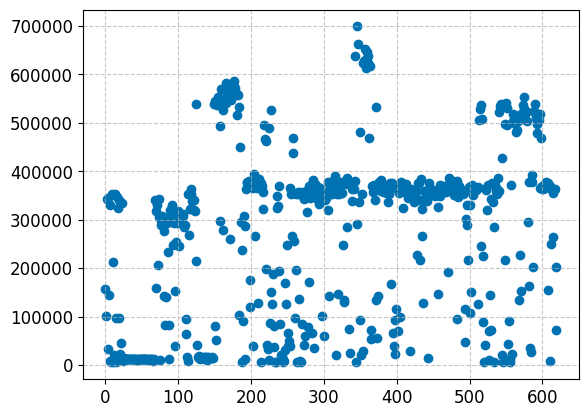

In [494]:
apply_global_style()
plt.scatter(range(len(scores)), scores)
plt.show()

In [482]:
outliers = np.where(np.array(scores) < 0.99)
outliers[0]

array([], dtype=int64)

In [467]:
len([8,  15, 188, 214, 263, 268, 520, 533, 546, 555])

10

In [468]:
scores.index(min(scores))

244

<BarContainer object of 96 artists>

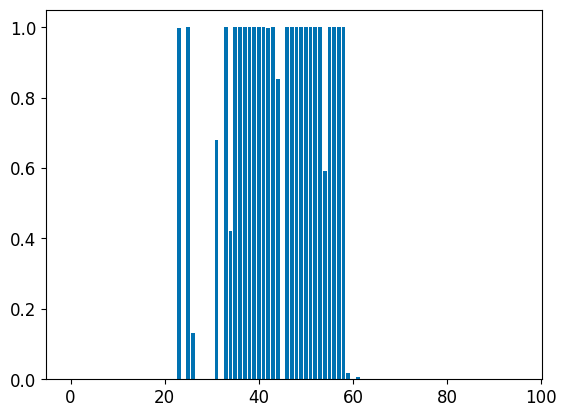

In [483]:
#rand = torch.randn(1, 1, latent_dim, device=device)
rand = torch.ones(1,1,20)
fake_sample = gen(rand).squeeze().detach().numpy()
plt.bar(range(len(fake_sample)), fake_sample)

<BarContainer object of 96 artists>

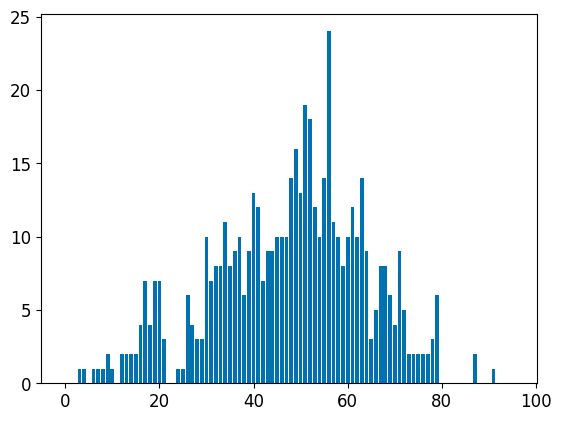

In [484]:
idx = 610
plt.bar(range(len(dataset[idx])), dataset[idx])

In [471]:
disc(torch.tensor(dataset[610]).unsqueeze(0)).detach().numpy()

array([[1.]], dtype=float32)